In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/soumyadebsaha/data12/indiavix.csv
/kaggle/input/datasets/soumyadebsaha/data12/banknifty.csv
/kaggle/input/datasets/soumyadebsaha/data12/README.md
/kaggle/input/datasets/soumyadebsaha/data12/starter_features.csv
/kaggle/input/datasets/soumyadebsaha/data12/nifty50.csv


# FEATURE ENGINEERING

### Creating a new feature 'Target Return' which is 1-D return shifted by 1 , ( so that row i feature , label row i+1 target)

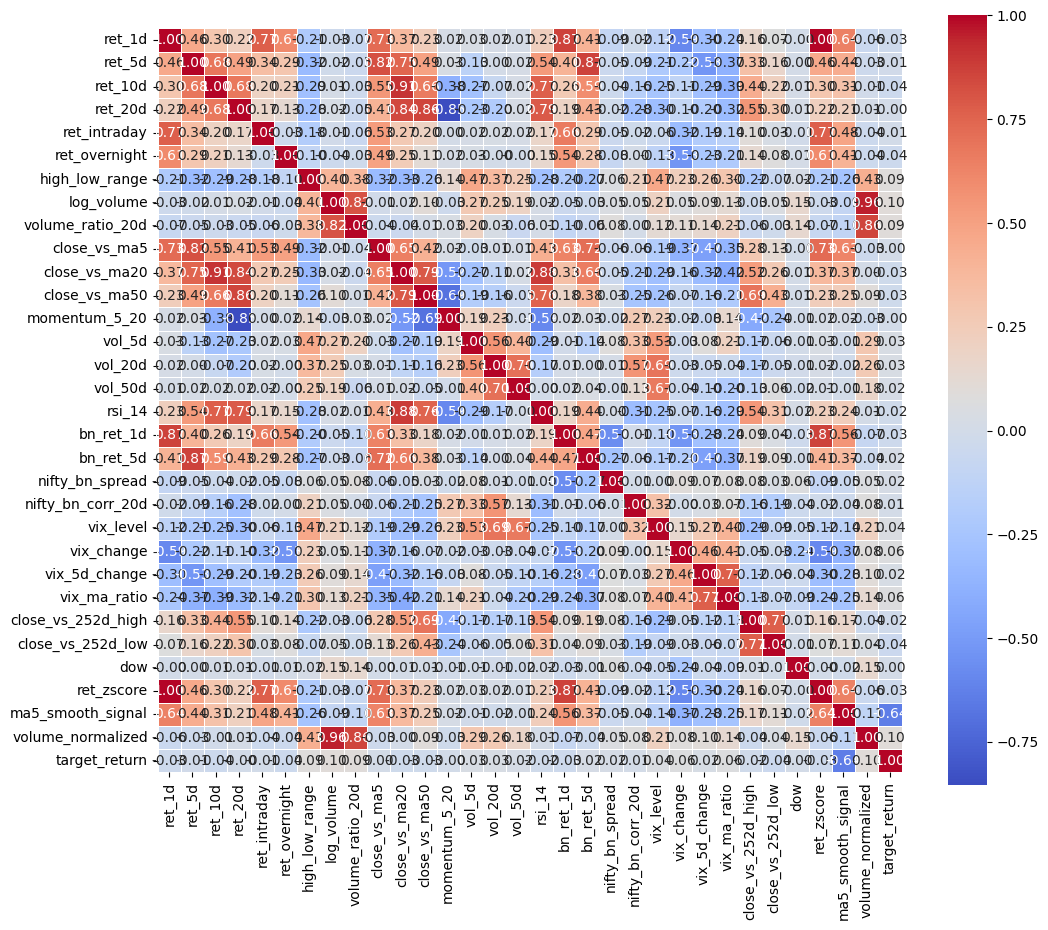

In [2]:
import pandas as pd
data =  pd.read_csv('/kaggle/input/datasets/soumyadebsaha/data12/starter_features.csv')


data['target_return'] = data['ret_1d'].shift(-1)

# dividing the dataset

insample_data = data[data['date'] <= '2025-06-30'].copy()
outsample_data = data[data['date'] > '2025-06-30'].copy()


# working with only insample
data=insample_data

data=data.drop('date', axis=1)

# correlation 

z= data.corr()

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 10))

# 4. Draw the heatmap
sns.heatmap(
    z, 
    annot=True,           # Show the numeric correlation values
    fmt=".2f",            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme (Red = Positive, Blue = Negative)
    linewidths=0.5, 
    square=True
)
plt.show()
# data


## cross-checking features from starter ( calculating from scratch)


In [3]:
import pandas as pd
import numpy as np

def calculate_rsi(series, period=14):
    """Standard RSI calculation with Wilder's Smoothing."""
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Initial average gain/loss using simple mean
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    
    # Apply Wilder's Smoothing for subsequent values
    # (Using a simple loop as it's the most mathematically accurate way for Wilder's)
    avg_gain_values = avg_gain.values
    avg_loss_values = avg_loss.values
    gain_values = gain.values
    loss_values = loss.values

    for i in range(period, len(series)):
        avg_gain_values[i] = (avg_gain_values[i-1] * (period - 1) + gain_values[i]) / period
        avg_loss_values[i] = (avg_loss_values[i-1] * (period - 1) + loss_values[i]) / period
        
    rs = avg_gain_values / avg_loss_values
    return 100 - (100 / (1 + rs))


def calculate_all_32_columns(df, bn_df, vix_df):
    
    for frame in [df, bn_df, vix_df]:
        frame['date'] = pd.to_datetime(frame['date'])
    
    df = df.merge(bn_df[['date', 'Close']], on='date', how='inner', suffixes=('', '_bn'))
    df = df.merge(vix_df[['date', 'Close']], on='date', how='inner', suffixes=('', '_vix'))
    
    for n in [1, 5, 10, 20]:
        df[f'ret_{n}d'] = df['Close'].pct_change(n)
    
    df['ret_intraday'] = (df['Close'] - df['Open']) / df['Open']
    df['ret_overnight'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)    #gap-updown
    df['momentum_5_20'] = df['ret_5d'] - df['ret_20d']

    for n in [5, 20, 50]:
        df[f'close_vs_ma{n}'] = df['Close'] / df['Close'].rolling(n).mean() - 1

    for n in [5, 20, 50]:
        df[f'vol_{n}d'] = df['ret_1d'].rolling(n).std() * np.sqrt(252)
    
    df['log_volume'] = np.log1p(df['Volume'])
    df['volume_ratio_20d'] = df['Volume'] / df['Volume'].rolling(20).mean()
    df['volume_normalized'] = (df['Volume'] - df['Volume'].min()) / (df['Volume'].max() - df['Volume'].min())

    df['high_low_range'] = (df['High'] - df['Low']) / df['Low']
    df['close_vs_252d_high'] = df['Close'] / df['High'].rolling(252).max()
    df['close_vs_252d_low'] = df['Close'] / df['Low'].rolling(252).min()
    
    df['ret_zscore'] = (df['ret_1d'] - df['ret_1d'].rolling(5).mean()) / df['ret_1d'].rolling(5).std()   #issue (i assumed rolling 5)
    df['rsi_14'] = calculate_rsi( df['Close'], 14)

    df['bn_ret_1d'] = df['Close_bn'].pct_change()
    df['bn_ret_5d'] = df['Close_bn'].pct_change(5)
    df['nifty_bn_spread'] = df['ret_1d'] - df['bn_ret_1d']
    df['nifty_bn_corr_20d'] = df['ret_1d'].rolling(20).corr(df['bn_ret_1d'])
    df['vix_level'] = df['Close_vix']
    df['vix_change'] = df['vix_level'].pct_change()
    df['vix_5d_change'] = df['vix_level'].pct_change(5)
    df['vix_ma_ratio'] = df['vix_level'] / df['vix_level'].rolling(5).mean()    #issue ( here as well i assumed rolling 5)

    df['dow'] = df['date'].dt.dayofweek
    df['ma5_smooth_signal'] = df['ret_1d'].rolling(5).mean() # disaster (could't understand the quantity , so calculated rest)


    df['target_return'] = df['ret_1d'].shift(-1)
    df['target_binary'] = np.where(df['target_return'] > 0, 1, 0)
    return df

nifty = pd.read_csv('/kaggle/input/datasets/soumyadebsaha/data12/nifty50.csv')
bn = pd.read_csv('/kaggle/input/datasets/soumyadebsaha/data12/banknifty.csv')
vix = pd.read_csv('/kaggle/input/datasets/soumyadebsaha/data12/indiavix.csv')

final_df = calculate_all_32_columns(nifty, bn, vix)
final_df['date'] = pd.to_datetime(final_df['date'])

cutoff_date = pd.Timestamp('2025-06-30')
insample_data = final_df[final_df['date'] <= cutoff_date].copy()
outsample_data = final_df[final_df['date'] > cutoff_date].copy()

insample_data = insample_data.reset_index(drop=True)
outsample_data = outsample_data.reset_index(drop=True)

insample_data


,date,Adj Close,Close,High,Low,Open,Volume,Close_bn,Close_vix,ret_1d,...,nifty_bn_spread,nifty_bn_corr_20d,vix_level,vix_change,vix_5d_change,vix_ma_ratio,dow,ma5_smooth_signal,target_return,target_binary
0,2022-01-03,17625.699219,17625.699219,17646.650391,17383.300781,17387.150391,200500,36421.898438,16.450001,NaN,...,NaN,NaN,16.450001,NaN,NaN,NaN,0,NaN,0.010187,1
1,2022-01-04,17805.250000,17805.250000,17827.599609,17593.550781,17681.400391,247400,36840.148438,16.120001,0.010187,...,-0.001297,NaN,16.120001,-0.020061,NaN,NaN,1,NaN,0.006740,1
2,2022-01-05,17925.250000,17925.250000,17944.699219,17748.849609,17820.099609,251500,37695.898438,17.230000,0.006740,...,-0.016489,NaN,17.230000,0.068858,NaN,NaN,2,NaN,-0.010005,0
3,2022-01-06,17745.900391,17745.900391,17797.949219,17655.550781,17768.500000,236500,37490.250000,17.980000,-0.010005,...,-0.004550,NaN,17.980000,0.043529,NaN,NaN,3,NaN,0.003764,1
4,2022-01-07,17812.699219,17812.699219,17905.000000,17704.550781,17797.599609,239300,37739.601562,17.600000,0.003764,...,-0.002887,NaN,17.600000,-0.021135,NaN,1.030686,4,NaN,0.010700,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,2025-06-24,25044.349609,25044.349609,25317.699219,24999.699219,25179.900391,450200,56461.898438,13.640000,0.002901,...,-0.004279,0.842986,13.640000,-0.029181,-0.052778,0.975680,1,0.001551,0.008002,1
853,2025-06-25,25244.750000,25244.750000,25266.800781,25125.050781,25150.349609,260600,56621.148438,12.960000,0.008002,...,0.005181,0.836259,12.960000,-0.049853,-0.092437,0.944882,2,0.003485,0.012052,1
854,2025-06-26,25549.000000,25549.000000,25565.300781,25259.900391,25268.949219,428900,57206.699219,12.590000,0.012052,...,0.001710,0.853800,12.590000,-0.028549,-0.117111,0.940816,3,0.006047,0.003476,1
855,2025-06-27,25637.800781,25637.800781,25654.199219,25523.550781,25576.650391,564000,57443.898438,12.390000,0.003476,...,-0.000671,0.882199,12.390000,-0.015886,-0.093636,0.943928,4,0.004167,-0.004710,0


In [4]:
outsample_data = outsample_data[:-1]
outsample_data

,date,Adj Close,Close,High,Low,Open,Volume,Close_bn,Close_vix,ret_1d,...,nifty_bn_spread,nifty_bn_corr_20d,vix_level,vix_change,vix_5d_change,vix_ma_ratio,dow,ma5_smooth_signal,target_return,target_binary
0,2025-07-01,25541.800781,25541.800781,25593.400391,25501.800781,25551.349609,260700,57459.449219,12.53,0.000970,...,-0.001590,0.884064,12.53,-0.020328,-0.081378,0.990357,1,0.003958,-0.003461,0
1,2025-07-02,25453.400391,25453.400391,25608.099609,25378.750000,25588.300781,309800,56999.199219,12.45,-0.003461,...,0.004549,0.884075,12.45,-0.006385,-0.039352,0.992032,2,0.001665,-0.001890,0
2,2025-07-03,25405.300781,25405.300781,25587.500000,25384.349609,25505.099609,293400,56791.949219,12.39,-0.001890,...,0.001746,0.891692,12.39,-0.004819,-0.015886,0.990408,3,-0.001123,0.002192,1
3,2025-07-04,25461.000000,25461.000000,25470.250000,25331.650391,25428.849609,193500,57031.898438,12.32,0.002192,...,-0.002033,0.882237,12.32,-0.005650,-0.005650,0.985915,4,-0.001380,0.000012,1
4,2025-07-07,25461.300781,25461.300781,25489.800781,25407.250000,25450.449219,196100,56949.199219,12.56,0.000012,...,0.001462,0.880512,12.56,0.019481,-0.017983,1.008835,0,-0.000435,0.002404,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,2025-12-23,26177.150391,26177.150391,26233.550781,26119.050781,26205.199219,216600,59299.550781,9.38,0.000181,...,0.000257,0.907198,9.38,-0.030992,-0.067594,0.974444,1,0.002447,-0.001339,0
121,2025-12-24,26142.099609,26142.099609,26236.400391,26123.000000,26170.650391,188800,59183.601562,9.19,-0.001339,...,0.000616,0.870617,9.19,-0.020256,-0.066057,0.967776,2,0.002501,-0.003818,0
122,2025-12-26,26042.300781,26042.300781,26144.199219,26008.599609,26121.250000,142200,59011.351562,9.15,-0.003818,...,-0.000907,0.886875,9.15,-0.004353,-0.057673,0.975064,4,0.001760,-0.003848,0
123,2025-12-29,25942.099609,25942.099609,26106.800781,25920.300781,26063.349609,234300,58932.351562,9.72,-0.003848,...,-0.002509,0.881065,9.72,0.062295,0.021008,1.031409,0,-0.000178,-0.000125,0


### Error calculation of Calculated Vs Starter Feature

In [5]:
# Assuming 'starter_df' is the original data and 'final_df' is your calculated data

starter_df = pd.read_csv('/kaggle/input/datasets/soumyadebsaha/data12/starter_features.csv')
starter_df['date']= pd.to_datetime(starter_df['date'])

# We align them on the 'date' column first
comparison_df = pd.merge(
    starter_df[['date'] + list(starter_df.columns[1:])], 
    final_df[['date'] + list(final_df.columns[1:])], 
    on='date', 
    suffixes=('_starter', '_calc')
)

error_report = []

# List of columns to check (overlap between starter and your calculation)
base_cols = [col for col in starter_df.columns]

for col in base_cols:
    s_col = f"{col}_starter"
    c_col = f"{col}_calc"
    
    if s_col in comparison_df.columns and c_col in comparison_df.columns:
        # Calculate absolute difference, dropping NaNs as requested
        diff = (comparison_df[s_col] - comparison_df[c_col]).abs().dropna()
        mae = diff.mean()
        max_err = diff.max()
        
        error_report.append({
            'Feature': col,
            'MAE': mae,
            'Max Error': max_err,
        })

error_audit_df = pd.DataFrame(error_report)
print(error_audit_df)

               Feature           MAE     Max Error
0               ret_1d  2.166752e-05  1.174588e-02
1               ret_5d  1.406942e-04  1.797959e-02
2              ret_10d  3.158601e-04  1.773544e-02
3              ret_20d  6.205628e-04  2.164629e-02
4         ret_intraday  4.829972e-17  9.974660e-17
5        ret_overnight  2.155057e-05  1.171835e-02
6       high_low_range  6.392987e-05  2.457672e-03
7           log_volume  3.744338e-06  4.291753e-05
8     volume_ratio_20d  1.531899e-03  7.685191e-02
9         close_vs_ma5  3.493650e-05  4.517275e-03
10       close_vs_ma20  1.022658e-04  2.528249e-03
11       close_vs_ma50  1.740055e-04  2.971903e-03
12       momentum_5_20  6.645611e-04  2.291848e-02
13              vol_5d  1.086649e-01  5.733277e-01
14             vol_20d  1.187871e-01  2.813790e-01
15             vol_50d  1.209082e-01  2.235718e-01
16              rsi_14  7.304355e+00  2.905677e+01
17           bn_ret_1d  3.225164e-05  2.321380e-02
18           bn_ret_5d  1.80936

### Adding New Feature
#### Supertrend

In [6]:
def supertrend(df):
    atr_period = 10
    multiplier = 3
    
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))  # today's high - yesterday's close
    low_close = np.abs(df['Low'] - df['Close'].shift(1))  
    
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df['atr'] = true_range.rolling(atr_period).mean()
    
    hl2 = (df['High'] + df['Low']) / 2
    df['upperband_st'] = hl2 + (multiplier * df['atr'])
    df['lowerband_st'] = hl2 - (multiplier * df['atr'])
    df['s_t_indicator'] = (df['Close'] - df['lowerband_st']) / df['Close']
    return df
insample_data= supertrend(insample_data)
outsample_data= supertrend(outsample_data)


#### Bollinger BandW

In [7]:
def add_bb_width(df, period=20):
    ma = df['Close'].rolling(period).mean()
    std = df['Close'].rolling(period).std()
    upper = ma + (2 * std)
    lower = ma - (2 * std)
    df['bb_width'] = (upper - lower) / ma
    # Feature for the model: is volatility expanding or contracting?
    df['bb_width_velocity'] = df['bb_width'] / df['bb_width'].shift(5) 
    return df
insample_data =  add_bb_width(insample_data, period=20)
outsample_data = add_bb_width(outsample_data, period=20)

### Few experimental features

In [8]:
def more_fea(df):
    # Add this to calculate_all_32_columns
    df['bn_nifty_ratio'] = df['Close_bn'] / df['Close']
    df['bn_ratio_ret_5d'] = df['bn_nifty_ratio'].pct_change(5) # Strength of banks vs market
    df['vix_percentile'] = df['Close_vix'].rolling(21).apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1])
    df['gap_pct'] = (df['Open'] - df['Close'].shift(1)) / df['atr'].shift(1)
    return df


insample_data = more_fea(insample_data)
outsample_data = more_fea(outsample_data)
outsample_data

,date,Adj Close,Close,High,Low,Open,Volume,Close_bn,Close_vix,ret_1d,...,atr,upperband_st,lowerband_st,s_t_indicator,bb_width,bb_width_velocity,bn_nifty_ratio,bn_ratio_ret_5d,vix_percentile,gap_pct
0,2025-07-01,25541.800781,25541.800781,25593.400391,25501.800781,25551.349609,260700,57459.449219,12.53,0.000970,...,NaN,NaN,NaN,NaN,NaN,NaN,2.249624,NaN,NaN,NaN
1,2025-07-02,25453.400391,25453.400391,25608.099609,25378.750000,25588.300781,309800,56999.199219,12.45,-0.003461,...,NaN,NaN,NaN,NaN,NaN,NaN,2.239355,NaN,NaN,NaN
2,2025-07-03,25405.300781,25405.300781,25587.500000,25384.349609,25505.099609,293400,56791.949219,12.39,-0.001890,...,NaN,NaN,NaN,NaN,NaN,NaN,2.235437,NaN,NaN,NaN
3,2025-07-04,25461.000000,25461.000000,25470.250000,25331.650391,25428.849609,193500,57031.898438,12.32,0.002192,...,NaN,NaN,NaN,NaN,NaN,NaN,2.239971,NaN,NaN,NaN
4,2025-07-07,25461.300781,25461.300781,25489.800781,25407.250000,25450.449219,196100,56949.199219,12.56,0.000012,...,NaN,NaN,NaN,NaN,NaN,NaN,2.236696,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,2025-12-23,26177.150391,26177.150391,26233.550781,26119.050781,26205.199219,216600,59299.550781,9.38,0.000181,...,177.849805,26709.850195,25642.751367,0.020415,0.023354,1.106306,2.265317,-0.007678,0.047619,0.172940
121,2025-12-24,26142.099609,26142.099609,26236.400391,26123.000000,26170.650391,188800,59183.601562,9.19,-0.001339,...,167.879883,26683.339844,25676.060547,0.017827,0.022824,1.023607,2.263919,-0.008072,0.047619,-0.036548
122,2025-12-26,26042.300781,26042.300781,26144.199219,26008.599609,26121.250000,142200,59011.351562,9.15,-0.003818,...,158.484766,26551.853711,25600.945117,0.016948,0.021694,0.968248,2.265981,-0.007050,0.047619,-0.124194
123,2025-12-29,25942.099609,25942.099609,26106.800781,25920.300781,26063.349609,234300,58932.351562,9.72,-0.003848,...,161.229883,26497.240430,25529.861133,0.015891,0.020599,0.924147,2.271688,-0.001382,0.333333,0.132813


### correlation check to prevent collinearity

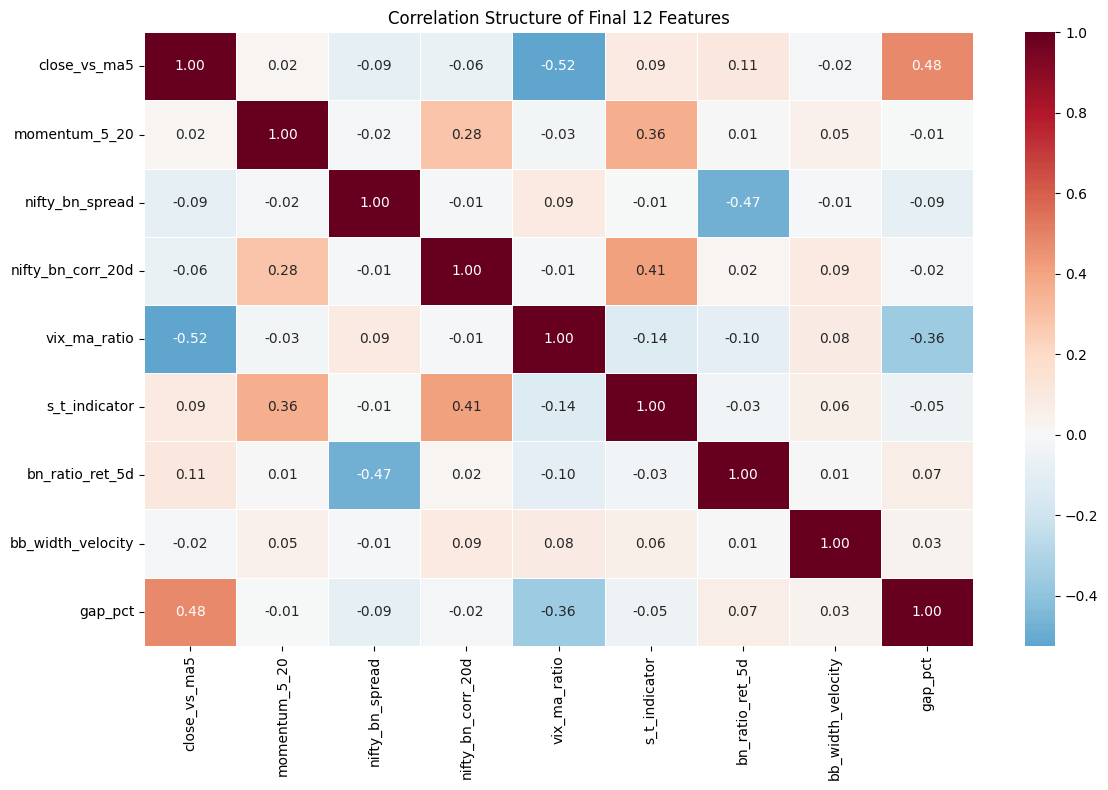

--- Pairs with Correlation > 0.7 ---
Empty DataFrame
Columns: [level_0, level_1, 0]
Index: []


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define your final 12-feature set
selected_features = [
     'close_vs_ma5', 'momentum_5_20', 
    'nifty_bn_spread', 'nifty_bn_corr_20d', 
    'vix_ma_ratio', 's_t_indicator', 'bn_ratio_ret_5d', 
    'bb_width_velocity', 'gap_pct'
]

# 2. Extract these features from your insample_data
# Ensure we drop any remaining NaNs to get an accurate correlation
corr_df = insample_data[selected_features].dropna()

# 3. Calculate Correlation Matrix
correlation_matrix = corr_df.corr()

# 4. Generate the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red-Blue centered at 0
    center=0,
    linewidths=0.5
)

plt.title("Correlation Structure of Final 12 Features")
plt.tight_layout()
plt.show()

# 5. Brief printout for Multicollinearity check
# High correlation (>0.7) suggests redundant features
high_corr = correlation_matrix.abs().stack().reset_index()
high_corr = high_corr[
    (high_corr[0] > 0.7) & (high_corr['level_0'] != high_corr['level_1'])
]
print("--- Pairs with Correlation > 0.7 ---")
print(high_corr)

# MODEL

## walk forward validated Xgboost

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb

def predict_return(final_df, window_size):
    feature_cols = [
                    'close_vs_ma5', 
                    'momentum_5_20', 
                    'nifty_bn_spread', 
                    'nifty_bn_corr_20d', 
                    'vix_ma_ratio', 
                    's_t_indicator' ,
                    'bn_ratio_ret_5d',
                    'bb_width_velocity',
                    'gap_pct'
                   ]
    
    target_col = 'target_binary'
    # target_col = 'target_return'
    
    preds = []
    actuals = []
    dates = []

    for i in range(window_size, len(final_df)):
        # sliding window
        X_train = final_df.loc[i - window_size : i - 1, feature_cols]
        y_train = final_df.loc[i - window_size : i - 1, target_col]

        # Predict for the current day (i)
        X_test = final_df.loc[[i], feature_cols]
        y_test = final_df.loc[i, target_col]

        # for using binary target
        model = xgb.XGBClassifier(
            n_estimators=50, 
            max_depth=3, 
            learning_rate=0.05, 
            random_state=42,
            objective='binary:logistic' 
        )

        # model = xgb.XGBRegressor(
        #     n_estimators=50, 
        #     max_depth=3, 
        #     learning_rate=0.05, 
        #     random_state=42,
        #     objective='reg:squarederror' 
        # )

        model.fit(X_train, y_train)
        # print(model.feature_importances_)
        
        preds.append(model.predict(X_test)[0])
        actuals.append(y_test)
        dates.append(final_df.loc[i, 'date'])

    return pd.DataFrame({'date': dates, 'Actual_Return': actuals, 'Predicted_Return': preds})

# EVALUATE

In [11]:
# Dividing the Insample dataset into 5 smaller subsets + outsample (providing statistical significance)

def evaluate(results_df):
    results_df['target'] = np.where(results_df['Actual_Return'] > 0, 1, 0)
    results_df['pred_target'] = np.where(results_df['Predicted_Return'] > 0, 1, 0)
    results_df['only_up']=1
    results_df['only_down']=0
    # results_df['Strat_Ret'] = results_df['pred_target'] * results_df['Actual_Return']
    # Calculate win rate
    # win_rate = (results_df['target'] == results_df['pred_target']).mean()
    win_rate = (results_df['Actual_Return'] == results_df['Predicted_Return']).mean()
    biased_up = (results_df['Actual_Return'] == results_df['only_up']).mean()
    biased_down = (results_df['Actual_Return'] == results_df['only_down']).mean()
    
    print(f"Win Rate my strat: {win_rate:.2%}")
    print(f"always up strat: {biased_up:.2%}")
    print(f"always down strat: {biased_down:.2%}")
    # 
    
    print(win_rate)


print("full insample_data")
r =predict_return(insample_data, window_size=15)
evaluate(r)
print( "Divided insample data into 10 sequential chucks for SATISTICAL validation")

insample_chunk = np.array_split(insample_data, 10)
for i in range(10):
    # Reset index so each chunk starts from 0
    current_chunk = insample_chunk[i].reset_index(drop=True) 
    d = predict_return(current_chunk, window_size=15)
    evaluate(d)
    print("---------------")
    

full insample_data
Win Rate my strat: 55.23%
always up strat: 53.21%
always down strat: 46.79%
0.5522565320665083
Divided insample data into 10 sequential chucks for SATISTICAL validation


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Win Rate my strat: 56.34%
always up strat: 40.85%
always down strat: 59.15%
0.5633802816901409
---------------
Win Rate my strat: 59.15%
always up strat: 57.75%
always down strat: 42.25%
0.5915492957746479
---------------
Win Rate my strat: 46.48%
always up strat: 54.93%
always down strat: 45.07%
0.4647887323943662
---------------
Win Rate my strat: 60.56%
always up strat: 56.34%
always down strat: 43.66%
0.6056338028169014
---------------
Win Rate my strat: 60.56%
always up strat: 61.97%
always down strat: 38.03%
0.6056338028169014
---------------
Win Rate my strat: 60.56%
always up strat: 61.97%
always down strat: 38.03%
0.6056338028169014
---------------
Win Rate my strat: 49.30%
always up strat: 57.75%
always down strat: 42.25%
0.49295774647887325
---------------
Win Rate my strat: 64.29%
always up strat: 57.14%
always down strat: 42.86%
0.6428571428571429
---------------
Win Rate my strat: 48.57%
always up strat: 40.00%
always down strat: 60.00%
0.4857142857142857
---------------


### outsample

In [12]:
r2 =predict_return(outsample_data, window_size=15)
evaluate(r2)

Win Rate my strat: 57.27%
always up strat: 52.73%
always down strat: 47.27%
0.5727272727272728


## statistical quantities

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.utils import resample

def calculate_backtest_metrics(actual_rets, preds):
    # Ensure inputs are arrays
    preds = np.array(preds)
    actual_rets = np.array(actual_rets)
    
    # --- FIX: Convert 0 to -1 for a Long/Short strategy ---
    signal = np.where(preds == 1, 1, -1)
    
    # Strategy Returns: Signal * Market Return
    strat_rets = signal * actual_rets
    
    # Sharpe Ratio (Annualized)
    if strat_rets.std() == 0: return 0, 0, 0, 0
    sharpe = np.sqrt(252) * strat_rets.mean() / strat_rets.std()
    
    # Hit Rate
    y_true = (actual_rets > 0).astype(int)
    hit_rate = (preds == y_true).mean()
    
    # Turnover
    turnover = np.abs(pd.Series(preds).diff()).mean()
    
    return sharpe, hit_rate, turnover
    
def bootstrap_metrics(actual_rets, preds, n_iterations=1000):
    metrics_list = []
    
    for _ in range(n_iterations):
        # Resample with replacement
        indices = resample(np.arange(len(preds)))
        resampled_actual = actual_rets[indices]
        resampled_preds = preds[indices]
        
        # Binary target for classification metrics
        y_true = (resampled_actual > 0).astype(int)
        
        auc = roc_auc_score(y_true, resampled_preds)
        b_acc = balanced_accuracy_score(y_true, resampled_preds)
        sharpe, hit, turn = calculate_backtest_metrics(resampled_actual, resampled_preds)
        
        metrics_list.append([auc, b_acc, sharpe, hit, turn])
    
    metrics_df = pd.DataFrame(metrics_list, columns=['AUC', 'Bal_Acc', 'Sharpe', 'HitRate', 'Turnover'])
    
    # Calculate 95% Confidence Intervals
    results = {}
    for col in metrics_df.columns:
        results[col] = {
            'Mean': metrics_df[col].mean(),
            'Lower_CI': metrics_df[col].quantile(0.025),
            'Upper_CI': metrics_df[col].quantile(0.975)
        }
    return results, confusion_matrix((actual_rets > 0).astype(int), preds)

# --- EXECUTION ---
# Using your outsample results 'r2' from your Kaggle notebook
actual_returns = r2['Actual_Return'].values
predicted_labels = r2['Predicted_Return'].values

stats, cm = bootstrap_metrics(actual_returns, predicted_labels)

print("--- OUT-OF-SAMPLE RESULTS (JULY - DEC 2025) ---")
for metric, val in stats.items():
    print(f"{metric}: {val['Mean']:.4f} [95% CI: {val['Lower_CI']:.4f} to {val['Upper_CI']:.4f}]")

print("\n--- CONFUSION MATRIX ---")
print(cm)

--- OUT-OF-SAMPLE RESULTS (JULY - DEC 2025) ---
AUC: 0.5709 [95% CI: 0.4808 to 0.6583]
Bal_Acc: 0.5709 [95% CI: 0.4808 to 0.6583]
Sharpe: 2.8526 [95% CI: -0.1972 to 5.8298]
HitRate: 0.5738 [95% CI: 0.4818 to 0.6636]
Turnover: 0.4942 [95% CI: 0.4037 to 0.5872]

--- CONFUSION MATRIX ---
[[27 25]
 [22 36]]
